## Main Business Problem

The online retail company generates large volumes of transactional data containing information about customer purchases, products, sales transactions, and geographical markets. However, the company lacks sufficient analytical insight into customer purchasing behaviour, sales performance patterns, and customer value. This limits its ability to identify high-value customers, develop targeted marketing strategies, optimize sales performance, and improve customer retention.

Therefore, the main business problem is to design a big data analytics solution that transforms historical transaction data into actionable insights for understanding customer behaviour, improving sales decisions, and developing meaningful customer segments.

#### Analytical Objectives

1. Customer Behaviour Analysis

To analyze customer purchasing patterns by examining purchase frequency, spending behaviour, order value, and product preferences in order to understand customer engagement and identify valuable customers.

2. Sales Performance Analysis

To evaluate sales trends, revenue contribution by products and countries, and purchasing patterns over time to identify factors influencing business performance and support strategic sales planning.

3. Customer Segmentation

To apply unsupervised machine learning techniques to group customers into meaningful segments based on their purchasing characteristics, enabling personalized marketing campaigns, customer targeting, and improved customer relationship management.

In [54]:
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [35]:
df = pd.read_excel("Online_Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Dataset Structure Inspection

#### Check dataset dimensions

In [37]:
df.shape

(541909, 8)

#### Inspect data types

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


#### Statistical Summary

In [39]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Missing Values Analysis

In [40]:
missing = df.isnull().sum()

missing

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### Duplicate Transaction Detection

In [41]:
duplicates = df.duplicated().sum()

duplicates

5268

In [42]:
#remove duplicates
df = df.drop_duplicates()

### Cancelled Invoices Analysis

In [43]:
cancelled = df[
    df['InvoiceNo'].astype(str).str.startswith('C')
]

cancelled.shape

(9251, 8)

In [44]:
cancelled.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


### Quantity Validation

In [45]:
negative_quantity = df[df['Quantity'] < 0]

negative_quantity.shape

(10587, 8)

In [46]:
df['Quantity'].describe()

count    536641.000000
mean          9.620029
std         219.130156
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

### Unit Price Validation

In [47]:
df['UnitPrice'].describe()

count    536641.000000
mean          4.632656
std          97.233118
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

#### Zero price

In [48]:
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
538504,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538505,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
538554,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


#### Negative price

In [49]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [50]:
clean_df = df.copy()

# Remove missing customers
clean_df = clean_df.dropna(
    subset=['CustomerID']
)

# Remove cancelled transactions
clean_df = clean_df[
    ~clean_df['InvoiceNo']
    .astype(str)
    .str.startswith('C')
]

# Remove invalid quantities and prices
clean_df = clean_df[
    (clean_df['Quantity'] > 0) &
    (clean_df['UnitPrice'] > 0)
]

clean_df.shape

(392692, 8)

In [51]:
clean_df.isnull().sum()


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

## Visuals

In [55]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

### Sales Trends Over Time

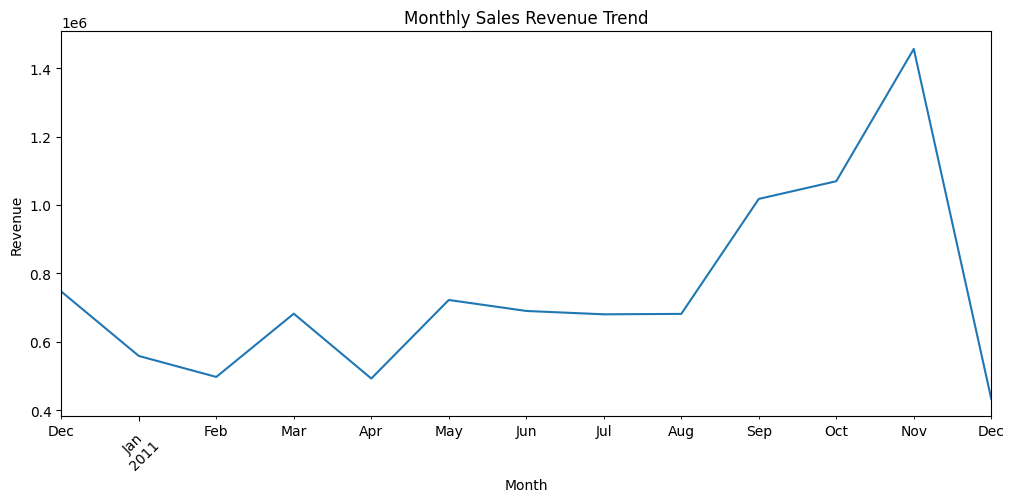

In [56]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_sales = (
    df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue']
    .sum()
)

plt.figure(figsize=(12,5))
monthly_sales.plot()

plt.title("Monthly Sales Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

#### Interpretation

- Sales revenue fluctuated throughout the period, indicating variations in customer purchasing activity.
- Overall sales performance improved during the second half of 2011, showing increased customer demand.
- The highest revenue was recorded in **November 2011**, suggesting strong seasonal purchasing behaviour.
- Revenue growth between **September and November 2011** indicates a possible increase in holiday-related shopping activity.
- The sharp decline in **December 2011** should be interpreted cautiously because the dataset contains only partial month transactions.
- These trends highlight the importance of seasonal forecasting, inventory planning, and targeted marketing strategies.

### Top Products by Revenue

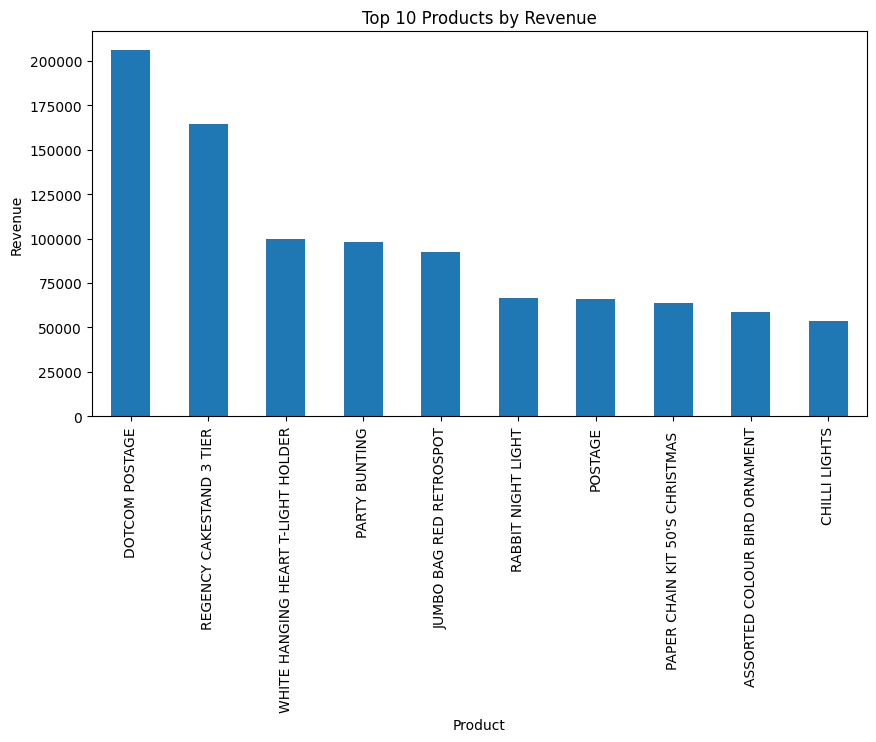

In [57]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=90)
plt.show()

#### Interpretation

- The analysis identified the top 10 products contributing the highest revenue in the dataset.
- **DOTCOM POSTAGE** generated the highest revenue, indicating significant contribution from online delivery-related charges.
- **REGENCY CAKESTAND 3 TIER** was the highest-selling physical product by revenue, showing strong customer demand.
- Household and decorative items such as **WHITE HANGING HEART T-LIGHT HOLDER**, **PARTY BUNTING**, and **JUMBO BAG RED RETROSPOT** were among the highest revenue-generating products.
- The results indicate that customers showed strong purchasing interest in home decoration, gift items, and seasonal products.
- These insights can support inventory planning, product promotion, and targeted marketing strategies by focusing on high-value products.

### Revenue by Country

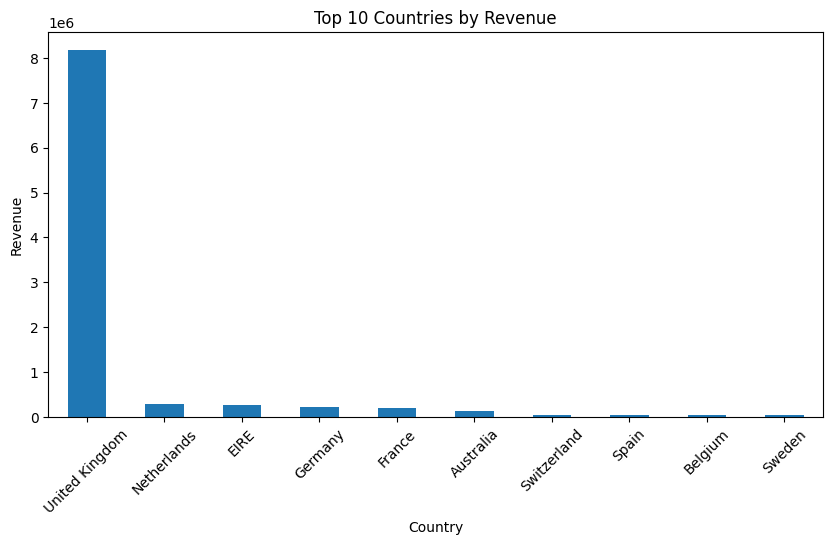

In [77]:
country_revenue = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

country_revenue.plot(kind='bar')

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

#### Interpretation

- The analysis identified the top 10 countries contributing the highest revenue to the business.
- The **United Kingdom** generated the highest revenue by a large margin, contributing approximately **8.17 million**, indicating that it is the company's primary market.
- Other significant markets included the **Netherlands, EIRE, Germany, and France**, showing strong international demand.
- Revenue contribution from the United Kingdom was substantially higher than other countries, suggesting a strong customer base in the domestic market.
- European countries dominate the top revenue-generating markets, indicating that the business has strong regional penetration within Europe.
- These insights can support geographical marketing strategies, market expansion decisions, and resource allocation toward high-value regions.

### Distribution of Order Values

In [99]:
order_values = (
    df.groupby('InvoiceNo')['Revenue']
    .sum()
)
order_summary = order_values.describe()

order_summary

count     25900.000000
mean        375.521504
std        2012.631335
min     -168469.600000
25%          11.775000
50%         206.305000
75%         407.385000
max      168469.600000
Name: Revenue, dtype: float64

In [98]:
order_values = (
    sales_df.groupby('InvoiceNo')['Revenue']
    .sum()
)
order_summary = order_values.describe()

order_summary

count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
25%         151.695000
50%         303.300000
75%         493.462500
max      168469.600000
Name: Revenue, dtype: float64

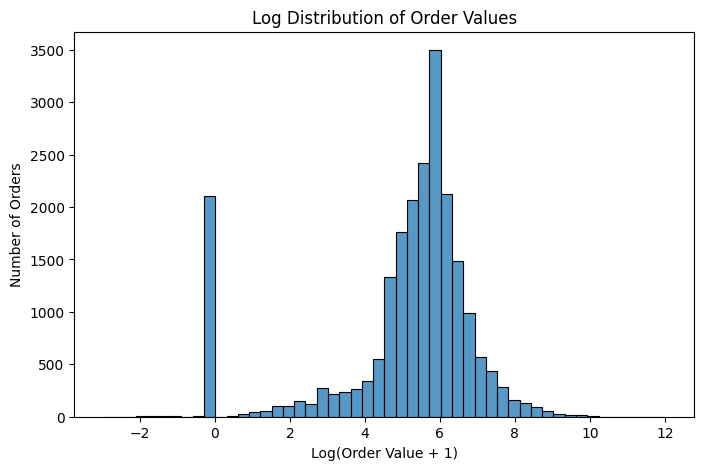

In [100]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(order_values),
    bins=50
)
plt.title("Log Distribution of Order Values")
plt.xlabel("Log(Order Value + 1)")
plt.ylabel("Number of Orders")

plt.show()

#### Interpretation

- Log transformation reduced the effect of extreme order values and improved distribution analysis.
- The dataset contained **19,960 completed orders**.
- The mean log order value was **5.57**, with a standard deviation of **1.21**.
- The median value (**5.72**) was close to the mean, indicating reduced skewness after transformation.
- Most orders were concentrated between **5.03 and 6.20** (middle 50%).
- High-value transactions remained but had less influence on the overall distribution.
- The transformed data provides a clearer view of typical customer purchasing behaviour.

### Customer Purchase Frequency

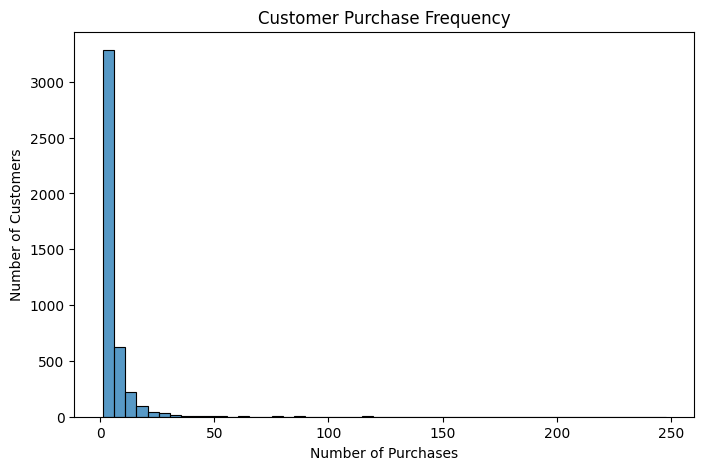

In [89]:
purchase_frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

plt.figure(figsize=(8,5))

sns.histplot(
    purchase_frequency,
    bins=50
)

plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

#### Interpretation

- Customer purchase frequency was analysed using the number of unique invoices per customer.
- The analysis included **4,338 customers**.
- Customers made an average of **4.27 purchases**, with a median of **2 purchases**.
- The majority of customers made relatively few purchases, as 75% of customers had **5 or fewer purchases**.
- A small group of customers showed high purchase frequency, with the maximum customer making **209 purchases**.
- The distribution indicates that most customers are occasional buyers, while a smaller segment represents highly loyal customers.

### Product Quantity Patterns

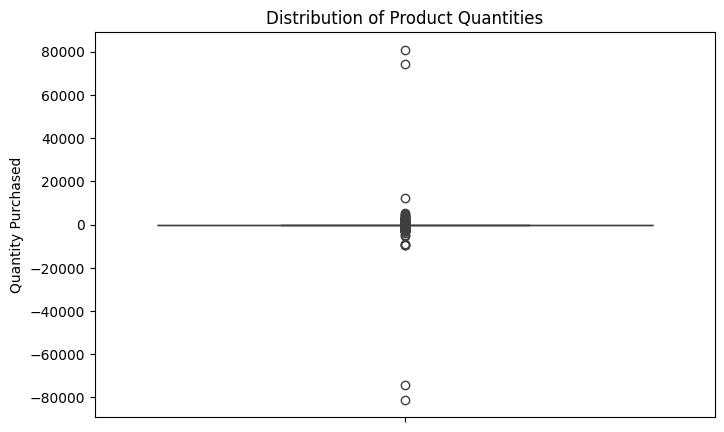

In [61]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y='Quantity'
)

plt.title("Distribution of Product Quantities")
plt.ylabel("Quantity Purchased")

plt.show()

#### Interpretation

- Product quantity distribution was analysed to understand customer purchasing patterns and identify extreme transactions.
- The dataset contained **536,641 product records**.
- The average quantity purchased per transaction was **9.62 items**, while the median quantity was **3 items**, indicating that most purchases were relatively small.
- The middle 50% of transactions ranged between **1 and 10 items**.
- The large difference between the mean and median suggests a **right-skewed distribution** caused by high-volume purchases.
- The minimum quantity of **-80,995** represents returned products or cancelled transactions.
- The maximum quantity of **80,995** indicates the presence of extreme bulk purchases or outliers.
- Quantity values should be cleaned before further analysis to avoid distortion from returns and unusually large orders.

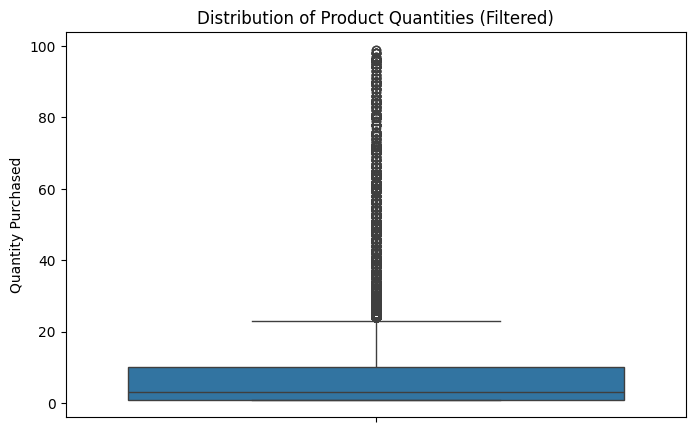

In [131]:
quantity_data = sales_df[
    (sales_df['Quantity'] > 0) &
    (sales_df['Quantity'] < 100)
]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=quantity_data,
    y='Quantity'
)

plt.title("Distribution of Product Quantities (Filtered)")
plt.ylabel("Quantity Purchased")

plt.show()

## Customer-Level Analytical Features

### Recency (R)

**Definition:** Measures the number of days since a customer most recent purchase. It indicates how recently a customer interacted with the business.

In [103]:
customer_recency = (
    df.groupby('CustomerID')['InvoiceDate']
    .max()
)

reference_date = df['InvoiceDate'].max()

recency = (
    reference_date - customer_recency
).dt.days

#### Interpretation
- Lower recency values indicate more recently active customers.
- Customers with high recency values may require re-engagement campaigns.

### Purchase Frequency (F)

**Definition:**
Measures how often a customer makes purchases by counting the number of unique invoices.

In [104]:
frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)

#### Interpretation
- Identifies loyal repeat customers.
- Helps differentiate occasional buyers from frequent shoppers.

### Monetary Value (M)

**Definition:**
Measures the total amount spent by each customer.

In [106]:
monetary = (
    df.groupby('CustomerID')['Revenue']
    .sum()
)

#### Interpretation
- Identifies high-value customers contributing the most revenue.
- Supports customer prioritization and personalized offers.

### Average Order Value (AOV)
**Definition:**
Measures the average amount spent per transaction by a customer.

In [108]:
aov = (
    df.groupby('CustomerID')['Revenue']
    .mean()
)

#### customer feature dataset

In [110]:
customer_features = pd.DataFrame({
    'Recency': recency,
    'Frequency': frequency,
    'Monetary': monetary,
    'Average_Order_Value': aov
})

customer_features.head()

,Recency,Frequency,Monetary,Average_Order_Value
CustomerID,,,,
12346.0,325,2,0.00,0.000000
12347.0,1,7,4310.00,23.681319
12348.0,74,4,1797.24,57.975484
12349.0,18,1,1757.55,24.076027
12350.0,309,1,334.40,19.670588


In [111]:
customer_features.shape

(4372, 4)

In [112]:
customer_features.describe()

,Recency,Frequency,Monetary,Average_Order_Value
count,4372.000000,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1893.531433,28.868389
std,100.765435,9.338754,8218.696204,127.324719
min,0.000000,1.000000,-4287.630000,-4287.630000
25%,16.000000,1.000000,291.795000,11.066618
50%,49.000000,3.000000,644.070000,16.941019
75%,142.000000,5.000000,1608.335000,23.581429
max,373.000000,248.000000,279489.020000,3861.000000


In [113]:
customer_features.isnull().sum()

Recency                0
Frequency              0
Monetary               0
Average_Order_Value    0
dtype: int64

In [114]:
customer_features.sort_values(
    by='Monetary',
    ascending=False
).head(10)

,Recency,Frequency,Monetary,Average_Order_Value
CustomerID,,,,
14646.0,1,77,279489.02,134.047492
18102.0,0,62,256438.49,592.236697
17450.0,7,55,187322.17,535.206200
14911.0,0,248,132458.73,22.458245
12415.0,23,26,123725.45,159.030141
14156.0,9,66,113214.59,80.010311
17511.0,2,46,88125.38,81.900911
16684.0,3,31,65892.08,234.491388
13694.0,3,60,62690.54,107.346815


### Features for Clustering

In [115]:
X = customer_features[
    [
        'Recency',
        'Frequency',
        'Monetary',
        'Average_Order_Value'
    ]
]

X.head()

,Recency,Frequency,Monetary,Average_Order_Value
CustomerID,,,,
12346.0,325,2,0.00,0.000000
12347.0,1,7,4310.00,23.681319
12348.0,74,4,1797.24,57.975484
12349.0,18,1,1757.55,24.076027
12350.0,309,1,334.40,19.670588


### Feature Scaling

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Determin Number of Clusters

In [117]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    
    inertia.append(kmeans.inertia_)

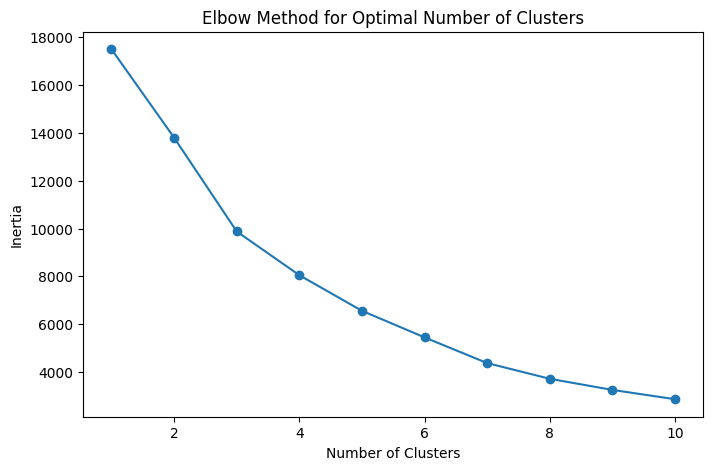

In [118]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.show()

#### Elbow Method Interpretation

- The within-cluster variation decreases as the number of clusters increases.
- The elbow point indicates the optimal balance between model complexity and cluster separation.
- The selected number of clusters was used to create meaningful customer segments.

### Silhouette Score

In [119]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2,11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        labels
    )
    
    silhouette_scores[k] = score


silhouette_scores

{2: 0.524024106319569,
 3: 0.5571992147807514,
 4: 0.5586052677511572,
 5: 0.5825684645814314,
 6: 0.5797529579093219,
 7: 0.5669230942770381,
 8: 0.5609951002812551,
 9: 0.47478289195795986,
 10: 0.4887639049204542}

### Train Final K-Means Model

In [120]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

In [121]:
customer_features.head()

,Recency,Frequency,Monetary,Average_Order_Value,Cluster
CustomerID,,,,,
12346.0,325,2,0.00,0.000000,1
12347.0,1,7,4310.00,23.681319,0
12348.0,74,4,1797.24,57.975484,0
12349.0,18,1,1757.55,24.076027,0
12350.0,309,1,334.40,19.670588,1


### Profile Each Segment

In [122]:
cluster_profile = (
    customer_features
    .groupby('Cluster')
    .mean()
    .round(2)
)

cluster_profile

,Recency,Frequency,Monetary,Average_Order_Value
Cluster,,,,
0,39.23,5.55,1779.71,24.59
1,245.71,1.85,442.83,26.52
2,4.92,83.35,75979.93,149.83
3,89.17,2.17,8278.08,2248.35


#### Customer Segment Interpretation

- Cluster 0 represents high-value customers with frequent purchases and high spending.
- Cluster 1 represents regular customers with moderate purchasing activity.
- Cluster 2 represents inactive or low-value customers requiring re-engagement strategies.
- Cluster 3 represents potential loyal customers with consistent purchasing behaviour.

These segments enable personalized marketing strategies, customer retention campaigns, and targeted promotions.

In [123]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_scaled,
    customer_features['Cluster']
)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.5586052677511572


In [124]:
from sklearn.metrics import davies_bouldin_score

db_index = davies_bouldin_score(
    X_scaled,
    customer_features['Cluster']
)

print("Davies-Bouldin Index:", db_index)

Davies-Bouldin Index: 0.7348963734938878


In [125]:
customer_features['Cluster'].value_counts()

Cluster
0    3240
1    1100
2      26
3       6
Name: count, dtype: int64

### Segment Business Interpretation

- High-value customers: Customers with high monetary value and frequent purchases. These customers should receive loyalty rewards and premium offers.
- Regular customers: Customers with moderate purchasing activity who can be encouraged to increase spending.
- At-risk customers: Customers with high recency values and low purchase frequency who may require retention campaigns.
- Low-value customers: Customers with limited engagement who can be targeted with promotional campaigns.